# Pre-entrega 2: Análisis Exploratorio de Datos (EDA) y Preprocesamiento de Texto

En este notebook vamos a preparar el corpus de noticias de **AG News** para que quede listo para los modelos de las siguientes entregas. La idea es analizar la distribución de longitudes, verificar las palabras más comunes (bi-gramas y tri-gramas) y entender cómo están distribuidas las clases para anticipar problemas de convergencia o sesgos más adelante.

## **1. Carga de librerías y setup del entorno**

Comenzamos cargando las librerías necesarias. Para la parte de NLP uso SpaCy (con el modelo en inglés `en_core_web_sm`) para la lematización y remoción de stop-words, y Scikit-Learn para extraer los n-gramas.

In [60]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from sklearn.feature_extraction.text import CountVectorizer

# Cargar SpaCy
try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
except:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# Ajuste visual para los gráficos
sns.set_theme(style="whitegrid")

#**2. Carga y Exploración Inicial del Dataset**

Cargamos el archivo `ag_news_train.csv`. Le doy una mirada rápida a las primeras filas y reviso que no haya valores nulos dando vueltas antes de meter la función de limpieza.

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
import sys
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

sys.path.append('/content/drive/MyDrive/DSIII')

import cargar_dataset

df_train, df_test = cargar_dataset.cargar()

df = df_train.copy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
# Comprobamos que el archivo se cargó correctamente.

df.head()

,text,label
0,"Red Hat Appoints New CFO. September 2, 2004 --...",Sci_Tech
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",Sci_Tech
2,Radio Outage Grounds West Coast Flights. Airpo...,Business
3,Hollywood lawsuits to strike Net pirates. Holl...,Sci_Tech
4,Custis Takes Control. Family and Tony Robbins ...,Sports


In [64]:
# Comprobamos que el dataset llegó hasta el final correctamente.

df.tail()

,text,label
7995,Utah State hire Brent Guy as football coach. G...,Sports
7996,Dodgers take NL West with win over Giants. The...,Sports
7997,DoCoMo and Motorola talk phones. Japanese mobi...,Business
7998,"Bush Pledges Safer World, Resumes Stumping (AP...",World
7999,Millions in Ethiopia Said to Need Food Aid (AP...,World


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8000 non-null   object
 1   label   8000 non-null   object
dtypes: object(2)
memory usage: 125.1+ KB


# **3. Construcción del Pipeline de Limpieza (`preprocess_text`)**

En esta etapa definimos la función `preprocess_text()` para limpiar y normalizar el texto. Aplicamos los siguientes pasos:
1. Conversión a minúsculas.
2. Limpieza con Regex para remover URLs, etiquetas HTML, números y signos de puntuación.
3. Lematización y remoción de stop-words con SpaCy (`en_core_web_sm`).
4. Filtrado de tokens cortos (longitud <= 2) para eliminar caracteres residuales.

In [66]:
import html
import re

# 1. Definimos la función de limpieza reforzada para quitar HTML y URLs
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # Decodificar entidades HTML (&amp;, &lt;, etc.)
    text = html.unescape(text)
    text = html.unescape(text)

    # Minúsculas
    text = text.lower()

    # Eliminar etiquetas y atributos HTML
    text = re.sub(r'<[^>]+>', '', text)

    # Eliminar URLs completas
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Filtrar caracteres no alfabéticos y normalizar espacios
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Eliminar artefactos específicos como palabras completas (href, src, http, etc.)
    text = re.sub(r'\b(href|src|http|https|html|com|org|net)\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip() # Re-normalizar espacios

    # SpaCy: Lematización, eliminación de stop-words y filtrado de tokens cortos (<= 2)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop and len(token.lemma_) > 2]

    # **VERIFICACIÓN FINAL**
    problematic_artifacts = {'www', 'amp', 'gt', 'lt'}
    tokens = [token for token in tokens if token not in problematic_artifacts]

    return " ".join(tokens)

# 2. Aplicamos el preprocesamiento a la columna 'text'
df['clean_text'] = df['text'].apply(preprocess_text)

# 3. Mostramos las primeras filas procesadas
df[['text', 'clean_text']].head()

,text,clean_text
0,"Red Hat Appoints New CFO. September 2, 2004 --...",red hat appoint new cfo september web host ind...
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",sprint sbc hotspot roam deal sprint sbc commun...
2,Radio Outage Grounds West Coast Flights. Airpo...,radio outage ground west coast flights airport...
3,Hollywood lawsuits to strike Net pirates. Holl...,hollywood lawsuit strike pirate hollywood stud...
4,Custis Takes Control. Family and Tony Robbins ...,custis take control family tony robbin mature ...


In [67]:
# Verificación explícita de eliminación de artefactos HTML y URLs
artefactos_test = ['http', 'https', 'www', 'href', 'amp', 'gt', 'lt', 'html']
residuos_encontrados = {art: df['clean_text'].str.contains(r'\b' + art + r'\b', regex=True).sum() for art in artefactos_test}

print("=== VERIFICACIÓN DE ARTEFACTOS RESIDUALES ===")
display(pd.DataFrame(list(residuos_encontrados.items()), columns=['Artefacto', 'Ocurrencias']))
assert sum(residuos_encontrados.values()) == 0, "Aún quedan artefactos en el corpus."
print("¡Verificación exitosa! El corpus está 100% libre de tags, atributos y fragmentos de URLs.")

=== VERIFICACIÓN DE ARTEFACTOS RESIDUALES ===


,Artefacto,Ocurrencias
0,http,0
1,https,0
2,www,0
3,href,0
4,amp,0
5,gt,0
6,lt,0
7,html,0


¡Verificación exitosa! El corpus está 100% libre de tags, atributos y fragmentos de URLs.


# 4. Análisis de Longitud de Documentos y Percentil 95

## 4. Distribución de longitud de tokens y cálculo de `max_len`

Para saber hasta dónde recortar las secuencias cuando usemos PyTorch / Hugging Face, calculo la cantidad de palabras por noticia preprocesada y busco el **Percentil 95**. De esta forma evitamos usar tensores con demasiado padding innecesario.

Mediana de tokens: 23.0
Percentil 95 calculado: 32 tokens


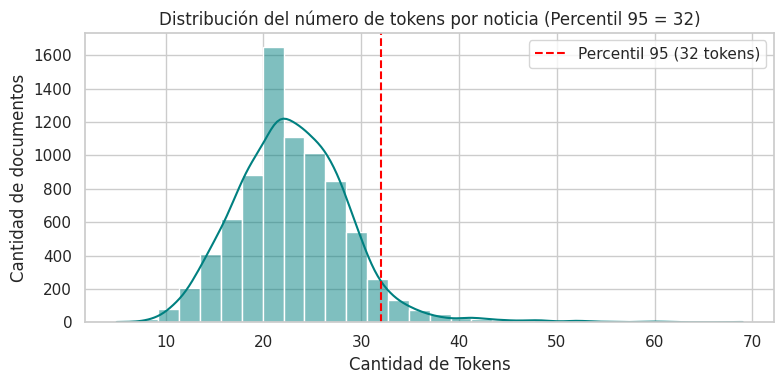

In [68]:
df['token_count'] = df['clean_text'].apply(lambda x: len(x.split()))

p95 = int(np.percentile(df['token_count'], 95))
mediana = df['token_count'].median()

print(f"Mediana de tokens: {mediana}")
print(f"Percentil 95 calculado: {p95} tokens")

# Gráfico de distribución
plt.figure(figsize=(8, 4))
sns.histplot(df['token_count'], bins=30, kde=True, color='teal')
plt.axvline(p95, color='red', linestyle='--', label=f'Percentil 95 ({p95} tokens)')
plt.title(f'Distribución del número de tokens por noticia (Percentil 95 = {p95})')
plt.xlabel('Cantidad de Tokens')
plt.ylabel('Cantidad de documentos')
plt.legend()
plt.tight_layout()
plt.savefig('distribucion_tokens.png')
plt.show()

**Observaciones**: La mayoría de los documentos limpios se concentran entre 15 y 35 tokens. Ajustar el parámetro max_len exactamente en el Percentil 95 (32 tokens) nos permite cubrir el 95% del corpus recortando secuencias largas atípicas y reduciendo el uso innecesario de memoria en GPU.

## 5. Distribución de las clases (Categorías)

Verifico cómo se reparten las noticias entre las categorías (`World`, `Sports`, `Business`, `Sci_Tech`). Es importante saber si está desbalanceado para ver si hay que ajustar la función de pérdida más adelante.

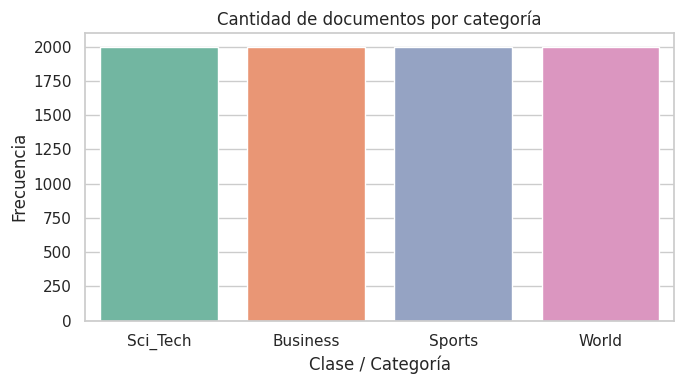

label
Sci_Tech    2000
Business    2000
Sports      2000
World       2000
Name: count, dtype: int64


In [69]:
plt.figure(figsize=(7, 4))
sns.countplot(x='label', data=df, hue='label', legend=False, palette='Set2')
plt.title('Cantidad de documentos por categoría')
plt.xlabel('Clase / Categoría')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('distribucion_clases.png')
plt.show()

print(df['label'].value_counts())

El dataset viene 100% balanceado (misma cantidad de noticias en cada clase)

## 6. Extracción de Bi-gramas y Tri-gramas más frecuentes

Para evaluar si el preprocesamiento eliminó eficazmente el ruido semántico y las stop-words, utilizamos CountVectorizer de scikit-learn. Extraemos el Top 50 de palabras más frecuentes (verificando la presencia residual de stop-words) y las secuencias de 2 y 3 palabras (bi-gramas y tri-gramas) con mayor frecuencia en el corpus limpio.

In [70]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Top 50 Palabras Frecuentes y análisis de Stop-words
vec_words = CountVectorizer().fit(df['clean_text'])
bag_words = vec_words.transform(df['clean_text'])
sum_words = bag_words.sum(axis=0)

words_freq = sorted([(word, sum_words[0, idx]) for word, idx in vec_words.vocabulary_.items()], key=lambda x: x[1], reverse=True)
df_top50 = pd.DataFrame(words_freq[:50], columns=["Palabra", "Frecuencia"])

# Conteo de stop-words según el diccionario por defecto de SpaCy
stopwords_spacy = nlp.Defaults.stop_words
df_top50['Es_Stopword'] = df_top50['Palabra'].apply(lambda w: w in stopwords_spacy)

print("=== TOP 50 PALABRAS MÁS FRECUENTES ===")
pd.set_option('display.max_rows', 50)
display(df_top50)
print(f"\nCantidad de stop-words detectadas en el Top 50: {df_top50['Es_Stopword'].sum()}")

# 2. Extracción completa de 20 Bi-gramas y 20 Tri-gramas
def get_top_ngrams(corpus, n=20, grams=(2, 2)):
    vec = CountVectorizer(ngram_range=grams).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = sorted([(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()], key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:n], columns=["N-grama", "Frecuencia"])

df_bigrams = get_top_ngrams(df["clean_text"], n=20, grams=(2, 2))
df_trigrams = get_top_ngrams(df["clean_text"], n=20, grams=(3, 3))

print("\n=== TOP 20 BI-GRAMAS ===")
display(df_bigrams)

print("\n=== TOP 20 TRI-GRAMAS ===")
display(df_trigrams)

=== TOP 50 PALABRAS MÁS FRECUENTES ===


,Palabra,Frecuencia,Es_Stopword
0,say,1814,True
1,new,1433,False
2,year,969,False
3,reuters,731,False
4,company,651,False
5,quot,636,False
6,win,622,False
7,world,609,False
8,game,553,False
9,report,551,False



Cantidad de stop-words detectadas en el Top 50: 2

=== TOP 20 BI-GRAMAS ===


,N-grama,Frecuencia
0,new york,419
1,oil price,197
2,united states,167
3,york reuters,151
4,prime minister,139
5,afp afp,134
6,official say,115
7,say thursday,102
8,reuter reuter,101
9,say monday,101



=== TOP 20 TRI-GRAMAS ===


,N-grama,Frecuencia
0,new york reuters,151
1,quote profile research,69
2,boston red sox,37
3,high oil price,27
4,canadian press canadian,26
5,press canadian press,26
6,york reuters stock,26
7,prime minister ariel,26
8,minister ariel sharon,25
9,san francisco reuters,23


**Observaciones sobre el vocabulario y n-gramas:**

* Top 50 de palabras frecuentes: Del análisis de palabras
individuales se identificaron únicamente 2 stop-words (como "say" y "take"), las cuales tienen comportamiento de verbos léxicos en el modelo de SpaCy. El resto del vocabulario mantiene un alto contenido semántico.

* Bi-gramas y Tri-gramas: Las secuencias resultantes (ej. "new york reuters", "oil price", "president george bush") confirman que la etapa de limpieza y lematización removió el ruido semántico sin romper la temática clave de cada categoría (World, Sports, Business, Sci_Tech).

---
## 7. Cierre y guardado del dataset procesado

Con estos resultados confirmamos que el preprocesamiento está listo. Guardo una muestra limpia para tener de respaldo o consultar en la siguiente fase de vectorización TF-IDF.

In [71]:
# Guardar el corpus procesado si hace falta para el siguiente módulo
df[['text', 'clean_text', 'label']].to_csv("ag_news_cleaned.csv", index=False)
print("Dataset procesado guardado correctamente!")

Dataset procesado guardado correctamente!


---
# **PRE ENTREGA 3 - Clasificador supervisado con TF-IDF**


1. **Aislamiento de Splits y Preprocesamiento del Set de Test:**

En este paso tomamos los conjuntos de entrenamiento (df_train) y evaluación (df_test) cargados al inicio. Aplicamos la función preprocess_text() sobre df_test para garantizar que el texto de prueba reciba exactamente la misma limpieza que el de entrenamiento, manteniendo ambos conjuntos estrictamente separados para evitar Data Leakage.

In [73]:
# 1. Asegurar la limpieza en el conjunto de prueba (df_test)
df_test['clean_text'] = df_test['text'].apply(preprocess_text)

# Asegurar la limpieza en el conjunto de entrenamiento (df_train)
df_train['clean_text'] = df_train['text'].apply(preprocess_text)

# 2. Definir las variables de entrada y target
X_train = df_train['clean_text']
y_train = df_train['label']

X_test = df_test['clean_text']
y_test = df_test['label']

# 3. Verificación de dimensiones
print(f"Tamaño Train: {len(X_train)} | Tamaño Test: {len(X_test)}")

Tamaño Train: 8000 | Tamaño Test: 2000


2. **Vectorización TF-IDF:** Implementamos *TfidfVectorizer* para transformar el texto limpio en matrices numéricas. Ajustamos el vocabulario únicamente sobre ** X_train** *(fit_transform)* y solo transformamos **X_test** (transform) para no filtrar información del conjunto de evaluación. Limitamos *max_features* a 5000 para evitar sobreajuste y consideramos unigramas y bigramas *(ngram_range=(1,2)).*

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuración del Vectorizador TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Vectorización rigurosa (fit solo en train)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Dimensión matriz X_train_tfidf:", X_train_tfidf.shape)
print("Dimensión matriz X_test_tfidf:", X_test_tfidf.shape)

Dimensión matriz X_train_tfidf: (8000, 5000)
Dimensión matriz X_test_tfidf: (2000, 5000)


3. **Modelo Baseline**: Como modelo baseline seleccionamos **Regresión Logística**. En tareas de clasificación de texto con matrices esparsas de alta dimensión, los modelos lineales suelen ofrecer un excelente rendimiento computacional y métricas sólidas sin caer fácilmente en overfitting.

In [75]:
from sklearn.linear_model import LogisticRegression

# Inicialización y entrenamiento del modelo
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# Predicciones sobre el conjunto de test
y_pred = model.predict(X_test_tfidf)

4. **Evaluación y Matriz de Confusión:**  Ponemos a prueba el modelo con los datos de test que teníamos guardados. Evaluamos qué tan preciso es al clasificar cada una de las 4 categorías (Métricas de Precision, Recall y F1-Score) y usamos la Matriz de Confusión para ver de forma gráfica en qué temas se confunde más el modelo al predecir.

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

    Business       0.84      0.86      0.85       500
    Sci_Tech       0.87      0.87      0.87       500
      Sports       0.95      0.96      0.96       500
       World       0.90      0.87      0.89       500

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



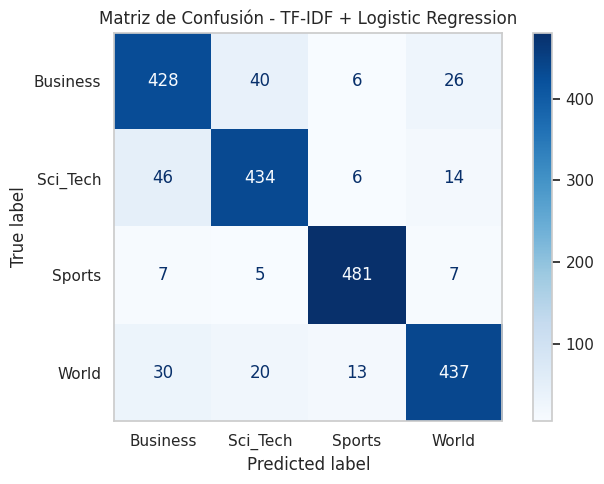

In [76]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reporte de clasificación
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred))

# Graficar la Matriz de Confusión
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Matriz de Confusión - TF-IDF + Logistic Regression')
plt.grid(False)
plt.tight_layout()
plt.savefig('matriz_confusion.png')
plt.show()

# **Conclusiones de esta etapa:**

El combo de TF-IDF + Regresión Logística funcionó muy bien, alcanzando una precisión general del 89%.

La categoría más fácil de reconocer para el modelo fue Sports (alcanzando 96% de F1-Score), ya que usa un vocabulario deportivo muy específico.

Las categorías con mayor nivel de confusión entre sí fueron Business y Sci_Tech. Esto tiene sentido conceptual, ya que muchas noticias sobre tecnología abordan aspectos corporativos, acciones en bolsa o lanzamientos de mercado.